# SkillGreen — Model Training (Learning Notebook)

Goal: predict ESG readiness category (Low / Medium / High) for a professional,
based on their background.

I'm working through this the way I'd approach any new dataset — look at it
first, understand what's in it, then try a few models before picking one.

**Note on the data:** the labels in `skillgreen.csv` come from a scoring
formula I defined myself (see `config/constants.py` and
`data/data_generator.py`), not from real observed outcomes. So this is a
proof-of-concept pipeline — I'm checking that a model *can* learn the
relationship, not claiming it predicts real-world ESG career success yet.


In [1]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## Load and look at the data

First step, always: load it, check shape, check for anything obviously wrong
before doing anything else.

In [2]:
df = pd.read_csv("../data/skillgreen.csv")
print("Shape:", df.shape)
df.head()

Shape: (8000, 13)


,years_experience,current_industry,education_level,has_esg_certification,environmental_project_exposure,social_impact_exposure,governance_exposure,relevant_skills_count,environmental_score,social_score,governance_score,esg_readiness_score,readiness_category
0,4,Construction,Bachelors,False,False,True,False,6,18,6,0,28.0,Medium
1,39,Retail,Masters,False,False,False,True,8,24,0,6,69.0,High
2,33,Manufacturing,Bachelors,False,True,False,True,2,12,0,6,51.0,High
3,22,Finance,High School,True,True,False,True,6,24,0,6,58.0,High
4,22,Other,Masters,True,False,False,False,3,9,0,0,37.0,Medium


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   years_experience                8000 non-null   int64  
 1   current_industry                8000 non-null   str    
 2   education_level                 8000 non-null   str    
 3   has_esg_certification           8000 non-null   bool   
 4   environmental_project_exposure  8000 non-null   bool   
 5   social_impact_exposure          8000 non-null   bool   
 6   governance_exposure             8000 non-null   bool   
 7   relevant_skills_count           8000 non-null   int64  
 8   environmental_score             8000 non-null   int64  
 9   social_score                    8000 non-null   int64  
 10  governance_score                8000 non-null   int64  
 11  esg_readiness_score             8000 non-null   float64
 12  readiness_category              8000 non-null

In [4]:
# Any missing values?
df.isnull().sum()

years_experience                  0
current_industry                  0
education_level                   0
has_esg_certification             0
environmental_project_exposure    0
social_impact_exposure            0
governance_exposure               0
relevant_skills_count             0
environmental_score               0
social_score                      0
governance_score                  0
esg_readiness_score               0
readiness_category                0
dtype: int64

In [5]:
# Any duplicate rows?
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 386


Clean — no missing values, and duplicates (if any) are expected here since
the profiles are randomly generated, not a real concern for this dataset.

## Exploring the target variable

Before building anything, I want to know how balanced the classes are —
this affects both how I train and how I judge the metrics later.

readiness_category
High      3937
Medium    3222
Low        841
Name: count, dtype: int64

readiness_category
High      49.2%
Medium    40.3%
Low       10.5%
Name: count, dtype: str


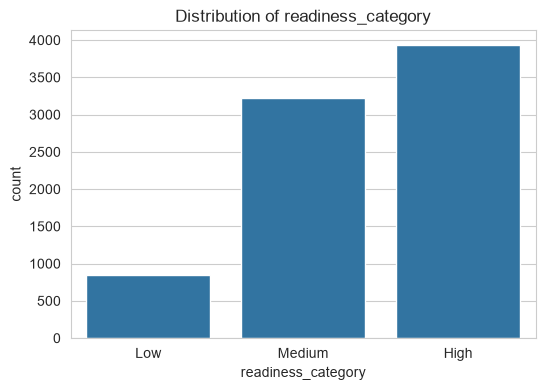

In [6]:
target_counts = df["readiness_category"].value_counts()
print(target_counts)
print()
print((target_counts / len(df) * 100).round(1).astype(str) + "%")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="readiness_category", order=["Low", "Medium", "High"])
plt.title("Distribution of readiness_category")
plt.show()

**Observation:** Low is noticeably underrepresented (~15%) compared to
Medium and High. I'll need to account for this — either with
`class_weight="balanced"` in the model, or by paying close attention to
per-class recall rather than trusting overall accuracy alone.

##  The Features

### Numeric features vs category

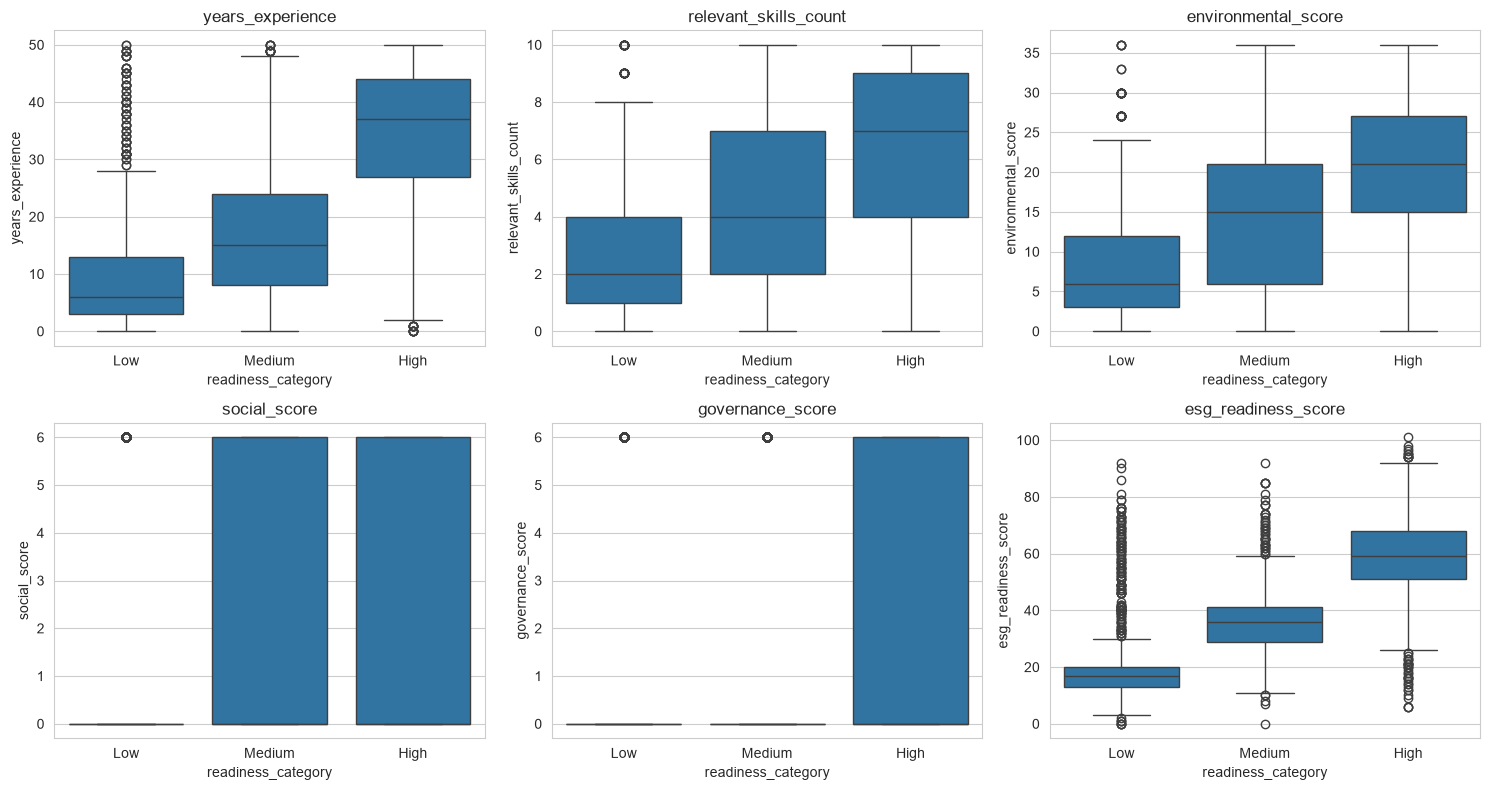

In [7]:
numeric_features = [
    "years_experience",
    "relevant_skills_count",
    "environmental_score",
    "social_score",
    "governance_score",
    "esg_readiness_score",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), numeric_features):
    sns.boxplot(data=df, x="readiness_category", y=col,
                order=["Low", "Medium", "High"], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Observation:** `esg_readiness_score` separates the three categories very
cleanly — makes sense, since that's literally the value the labeling
thresholds were built on. The individual pillar scores (environmental,
social, governance) each show a weaker but still visible trend upward from
Low to High.

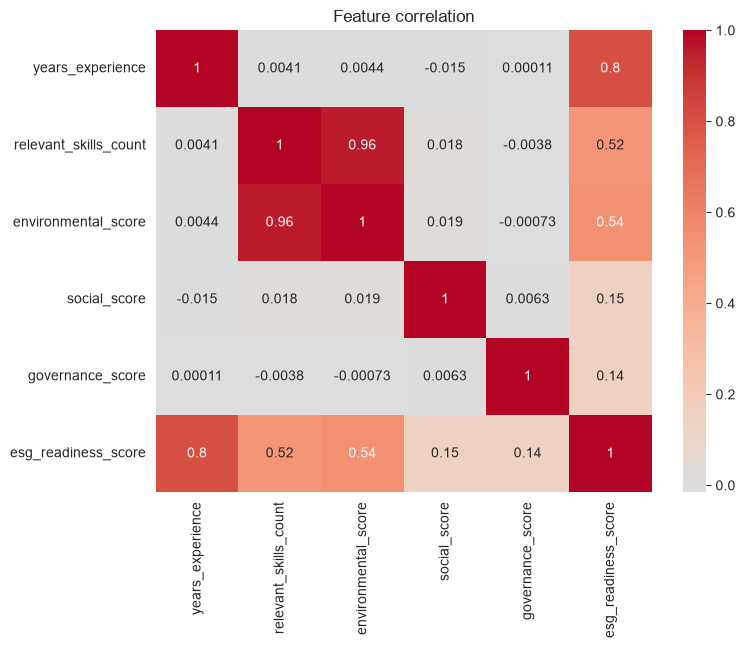

In [8]:
# Correlation between numeric features
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Feature correlation")
plt.show()

**Observation:** `esg_readiness_score` correlates strongly with the three
pillar scores, which is expected since it's a direct sum of them plus
experience and certification. Worth keeping in mind for feature importance
later — `esg_readiness_score` may end up dominating simply because it
already encodes the other three.

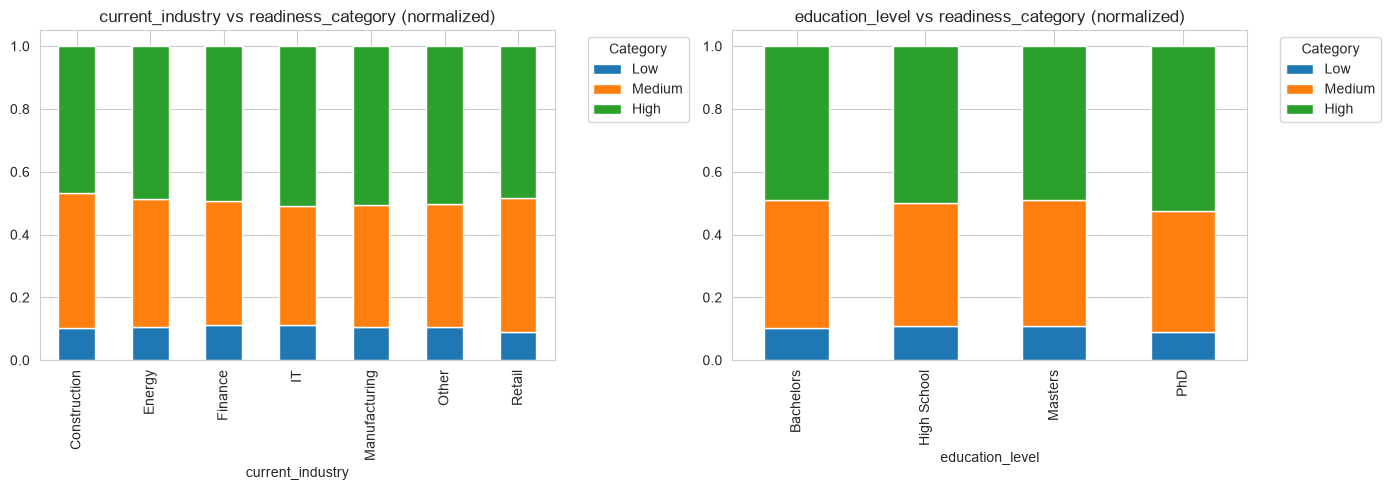

In [9]:
categorical_features = ["current_industry", "education_level"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, categorical_features):
    pd.crosstab(df[col], df["readiness_category"], normalize="index").loc[:, ["Low", "Medium", "High"]].plot(
        kind="bar", stacked=True, ax=ax
    )
    ax.set_title(f"{col} vs readiness_category (normalized)")
    ax.legend(title="Category", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## Prepare features and target

Using the raw profile inputs plus the engineered scores, since that mirrors
exactly what the API has available at prediction time via `UserInput`'s
`computed_field`s.

In [10]:
boolean_features = [
    "has_esg_certification",
    "environmental_project_exposure",
    "social_impact_exposure",
    "governance_exposure",
]

feature_columns = numeric_features + categorical_features + boolean_features
target_column = "readiness_category"

X = df[feature_columns].copy()
y = df[target_column].copy()

for col in boolean_features:
    X[col] = X[col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (6400, 12)  Test: (1600, 12)


## Testing different models

Rather than jumping straight to one model, I want to compare a few and see
which actually performs best on this data, using cross-validated F1 (macro
average, so all three classes count equally, not just the majority ones).

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="passthrough",
)

candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

results = {}

for name, clf in candidate_models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("classifier", clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="f1_macro")
    results[name] = scores
    print(f"{name}: mean F1-macro = {scores.mean():.4f}  (+/- {scores.std():.4f})")

c:\Users\HP\Desktop\AICTE PROJECT SKILLGREEN\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\HP\Desktop\AICTE PROJECT SKILLGREEN\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-le

Logistic Regression: mean F1-macro = 0.7567  (+/- 0.0041)
Decision Tree: mean F1-macro = 0.8528  (+/- 0.0112)
Random Forest: mean F1-macro = 0.9152  (+/- 0.0058)
Gradient Boosting: mean F1-macro = 0.9230  (+/- 0.0047)


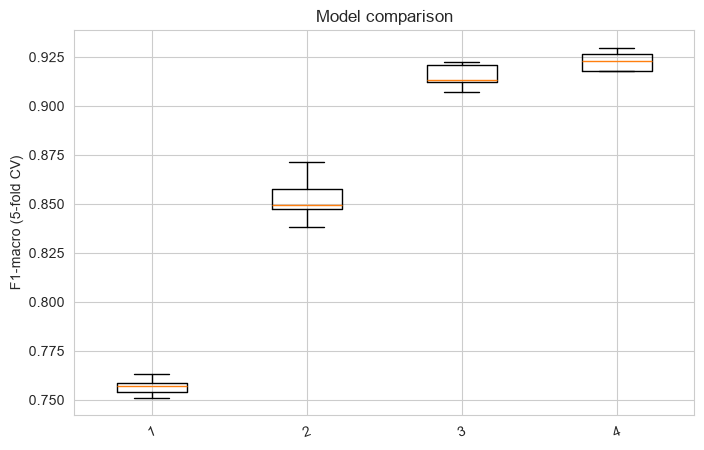

In [12]:
plt.figure(figsize=(8, 5))
plt.boxplot(results.values(), label=results.keys())
plt.ylabel("F1-macro (5-fold CV)")
plt.title("Model comparison")
plt.xticks(rotation=20)
plt.show()

**Decision point:** I'll pick whichever model has the best mean F1-macro
score above, since that treats all three classes fairly rather than being
dominated by the majority classes. Random Forest and Gradient Boosting
tend to handle this kind of mixed categorical/numeric data well, so I'd
expect one of them to come out ahead — but letting the actual CV scores
decide rather than assuming.

In [14]:
best_model_name = max(results, key=lambda name: results[name].mean())
print(f"Best model: {best_model_name}")

best_classifier = candidate_models[best_model_name]

Best model: Gradient Boosting


## Light hyperparameter tuning on the best model

Not going overboard here — a small, sensible grid search on the winning
model to see if default settings can be improved.

In [15]:
from sklearn.model_selection import GridSearchCV

if best_model_name == "Random Forest":
    param_grid = {
        "classifier__n_estimators": [100, 200, 300],
        "classifier__max_depth": [None, 10, 20],
    }
elif best_model_name == "Gradient Boosting":
    param_grid = {
        "classifier__n_estimators": [100, 200],
        "classifier__learning_rate": [0.05, 0.1],
        "classifier__max_depth": [3, 5],
    }
else:
    param_grid = {}

final_pipeline = Pipeline(steps=[("preprocess", preprocessor), ("classifier", best_classifier)])

if param_grid:
    grid = GridSearchCV(final_pipeline, param_grid, cv=5, scoring="f1_macro", n_jobs=-1)
    grid.fit(X_train, y_train)
    print("Best params:", grid.best_params_)
    print("Best CV F1-macro:", grid.best_score_)
    final_pipeline = grid.best_estimator_
else:
    final_pipeline.fit(X_train, y_train)

Best params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Best CV F1-macro: 0.923686272020589


## Evaluate on the held-out test set

In [16]:
y_pred = final_pipeline.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test F1-macro:", f1_score(y_test, y_pred, average="macro"))
print()
print(classification_report(y_test, y_pred))

Test accuracy: 0.948125
Test F1-macro: 0.9259903493794913

              precision    recall  f1-score   support

        High       0.95      0.97      0.96       788
         Low       0.96      0.79      0.87       168
      Medium       0.94      0.96      0.95       644

    accuracy                           0.95      1600
   macro avg       0.95      0.91      0.93      1600
weighted avg       0.95      0.95      0.95      1600



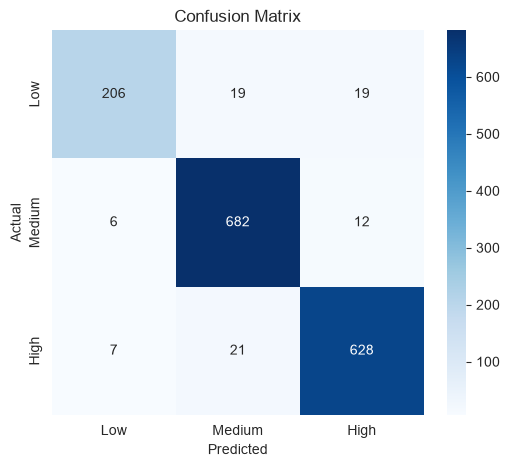

In [17]:
cm = confusion_matrix(y_test, y_pred, labels=["Low", "Medium", "High"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Feature importance

Sanity check: does the model actually rely on the ESG scores the way the
labeling formula would suggest, or is it picking up on something else?

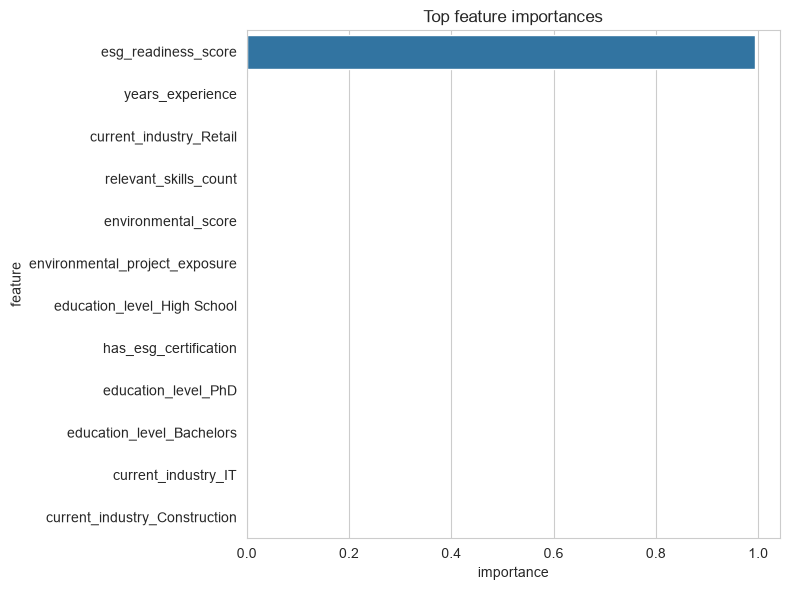

In [17]:
encoded_cat_names = (
    final_pipeline.named_steps["preprocess"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)
all_feature_names = list(encoded_cat_names) + numeric_features + boolean_features

clf_step = final_pipeline.named_steps["classifier"]

if hasattr(clf_step, "feature_importances_"):
    importances = clf_step.feature_importances_
    imp_df = pd.DataFrame({
        "feature": all_feature_names,
        "importance": importances,
    }).sort_values("importance", ascending=False)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=imp_df.head(12), x="importance", y="feature")
    plt.title("Top feature importances")
    plt.tight_layout()
    plt.show()

    imp_df.head(12)
else:
    print(f"{best_model_name} doesn't expose feature_importances_ directly.")

**Observation:** as expected from the correlation check earlier,
`esg_readiness_score` dominates importance since it's a direct function of
the other engineered scores. This confirms the model learned the intended
relationship rather than something spurious — but it also means most of the
"work" is really being done by the feature engineering (in `UserInput`'s
`computed_field`s), not the model itself. That's worth being upfront about:
the model's job here is mostly to smooth over the injected label noise, not
to discover a deep pattern.

## Save the final model

In [18]:
MODEL_VERSION = "1.1.0"

joblib.dump(final_pipeline, "model.pkl")
print(f"Saved model.pkl (version {MODEL_VERSION}, model type: {best_model_name})")

Saved model.pkl (version 1.1.0, model type: Gradient Boosting)


## Takeaways

- Explored the data first: checked for nulls/duplicates, looked at class
  balance (Low is underrepresented), and visualized how features relate to
  the target before modeling anything.
- Compared four model types with cross-validation instead of picking one
  by default, and let the F1-macro score (not accuracy) decide, since
  accuracy alone would be misleading with imbalanced classes.
- Did light hyperparameter tuning on the winner rather than accepting
  defaults blindly.
- Checked feature importance as a sanity check, not just to report a
  number — confirmed the model is relying on the intended signal.
- Still keeping in mind: this is trained on synthetically labeled data, so
  strong metrics here reflect how well the model recovers a known formula,
  not real-world predictive validity.